In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Exploratory Data Analysis

In [4]:
# Required imports
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import hashlib
import os
import cv2

In [5]:
# Set base directory for dataset
BASE_DIR = "/kaggle/input/cassava-leaf-disease-classification"

In [6]:
with open("/kaggle/input/cassava-leaf-disease-classification/label_num_to_disease_map.json") as file:
    print("yes")

yes


In [7]:
# Step 1: Load and inspect label map (mapping from numerical labels to disease names)
with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as file:
    map_classes = json.loads(file.read())
    map_classes = {int(k): v for k, v in map_classes.items()}

# Display the mapping
print("Class Mapping: ")
print(json.dumps(map_classes, indent=4))

Class Mapping: 
{
    "0": "Cassava Bacterial Blight (CBB)",
    "1": "Cassava Brown Streak Disease (CBSD)",
    "2": "Cassava Green Mottle (CGM)",
    "3": "Cassava Mosaic Disease (CMD)",
    "4": "Healthy"
}


In [8]:
os.listdir(os.path.join(BASE_DIR, "train_images"))[:5]

['1235188286.jpg',
 '1215607589.jpg',
 '478554372.jpg',
 '2763304605.jpg',
 '2826122413.jpg']

In [9]:
# Step 2: Load training image filenames and display the count
input_files = os.listdir(os.path.join(BASE_DIR, "train_images"))
print(f"Number of train images: {len(input_files)}")

Number of train images: 21397


In [10]:
# Step 3: Load train.csv and add a human-readable class name based on the mapping
df_train = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))
df_train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [11]:
df_train["class_name"] = df_train["label"].map(map_classes)
df_train

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


In [12]:
df_train['class_name'].value_counts()

class_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64

- Techniques like transfer leanirng, you dont need to balance hte data. Internally model will handle. ( Pre trained model )

- Scratch - then you need to do somehting about imbalance.. 



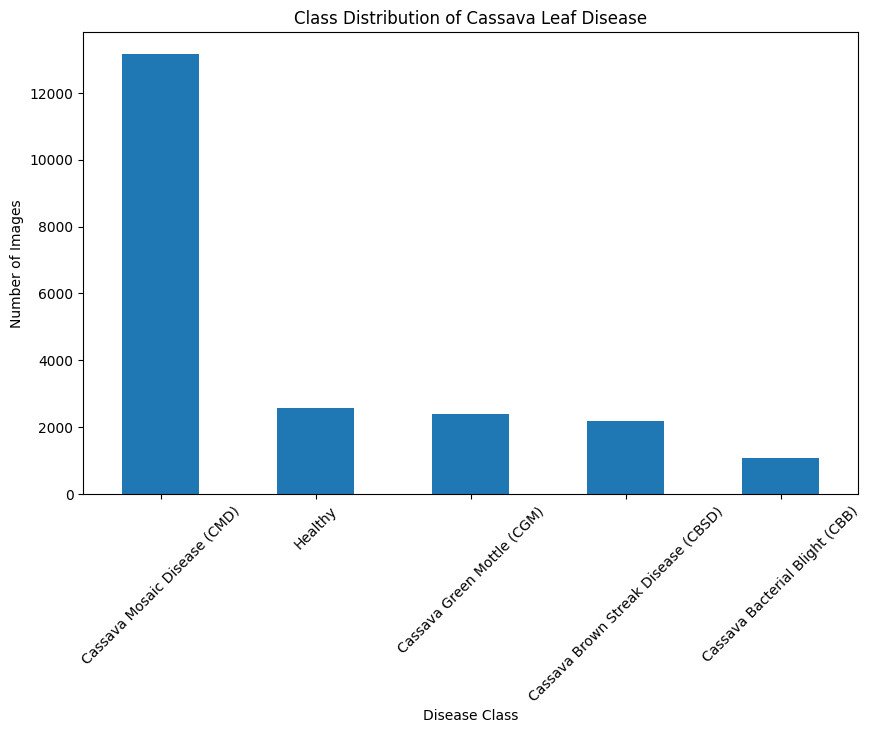

In [13]:
# Step 4: Check class distribution
class_distribution = df_train['class_name'].value_counts()
# Plot the class distribution
plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar')
plt.title('Class Distribution of Cassava Leaf Disease')
plt.ylabel('Number of Images')
plt.xlabel('Disease Class')
plt.xticks(rotation=45)
plt.show()

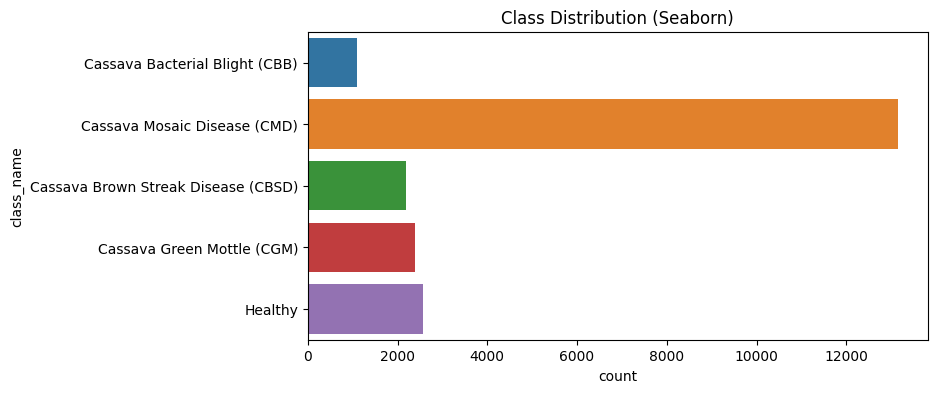

In [14]:
# Alternatively, use seaborn for a countplot visualization
plt.figure(figsize=(8, 4))
sns.countplot(y="class_name", data=df_train)
plt.title('Class Distribution (Seaborn)')
plt.show()


In [15]:
# Step 5: Basic dataset exploration
# Show data info and summary statistics
print("Dataset Info:")
print(df_train.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    21397 non-null  object
 1   label       21397 non-null  int64 
 2   class_name  21397 non-null  object
dtypes: int64(1), object(2)
memory usage: 501.6+ KB
None


In [16]:
print("\nDataset Summary Statistics:")
print(df_train.describe())


Dataset Summary Statistics:
              label
count  21397.000000
mean       2.651914
std        0.988565
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000


In [17]:
# Step 6: Check for missing values and duplicates
print(f"\nMissing values in each column:\n{df_train.isnull().sum()}")
print(f"Number of duplicate rows: {df_train.duplicated().sum()}")


Missing values in each column:
image_id      0
label         0
class_name    0
dtype: int64
Number of duplicate rows: 0


Images - 
let's check the shape of the images. 

Images - 50*50 ( very small pixels )
it doesn't make any sense to upscale to 224*224 ( mess up informaiton )

images 600 * 600 
resize to may be 224 224 
500 * 500

images size distributin you need to tune your resize image size.

In [18]:
path = "/kaggle/input/cassava-leaf-disease-classification/train_images/1000015157.jpg"
path2 = "1000015157.jpg"


cv2.imread(path2)

In [19]:
cv2.imread(path2)

In [25]:
# Step 7: Analyze image shapes (size dimensions) for a sample of 300 images
# Dictionary to store image shapes and their counts
img_shapes = {}
for image_name in os.listdir(os.path.join(BASE_DIR, "train_images"))[:1000]:
    image = cv2.imread(os.path.join(BASE_DIR, "train_images", image_name))
    img_shapes[image.shape] = img_shapes.get(image.shape, 0) + 1

# Display image shapes
print("\nSample Image Shapes and their Frequencies (from 1000 images):")
print(img_shapes)


Sample Image Shapes and their Frequencies (from 1000 images):
{(600, 800, 3): 1000}


I have my images with the size 600 * 800 * 3 ( rgb channels ) color full image.

<Figure size 1000x600 with 0 Axes>

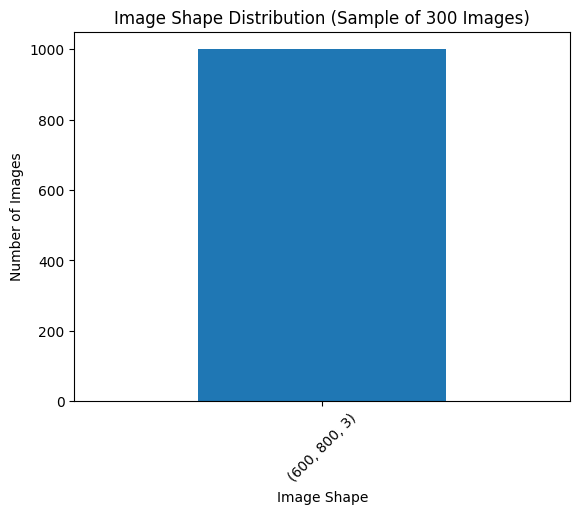

In [26]:
# Plot the image size distribution
img_shapes_df = pd.DataFrame(list(img_shapes.items()), columns=['Image Shape', 'Count'])
plt.figure(figsize=(10, 6))
img_shapes_df.sort_values(by='Count', ascending=False).plot(kind='bar', x='Image Shape', y='Count', legend=False)
plt.title('Image Shape Distribution (Sample of 300 Images)')
plt.xlabel('Image Shape')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()


In [27]:
df_train.head()

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


In [28]:
# Step 8: Function to plot sample images from a specific class
def plot_images_from_class(class_id, num_images=9):
    """
    Plot sample images from a specific class in a 3x3 grid.
    
    Parameters:
        class_id (int): The class label to filter images.
        num_images (int): The number of images to plot.
    """
    # Filter images for the specified class
    class_images = df_train[df_train['label'] == class_id]
    num_images = min(len(class_images), num_images)  # Adjust if fewer images than requested
    
    plt.figure(figsize=(15, 15))  # Set figure size for better visualization
    images = class_images.sample(num_images)  # Randomly sample images
    
    # Plot images in a 3x3 grid
    for i, (_, row) in enumerate(images.iterrows()):
        img_path = os.path.join(BASE_DIR, "train_images", row['image_id'])
        img = Image.open(img_path)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(map_classes[class_id])  # Use class name for the title
        plt.axis('off')  # Hide axis for better visualization
    
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()


In [1]:
# plot_images_from_class(0)

In [2]:
# # Step 9: Visualize sample images for each class (0 to 4)
# for i in range(5):
#     print(f"Displaying sample images for class: {map_classes[i]}")
#     plot_images_from_class(i)

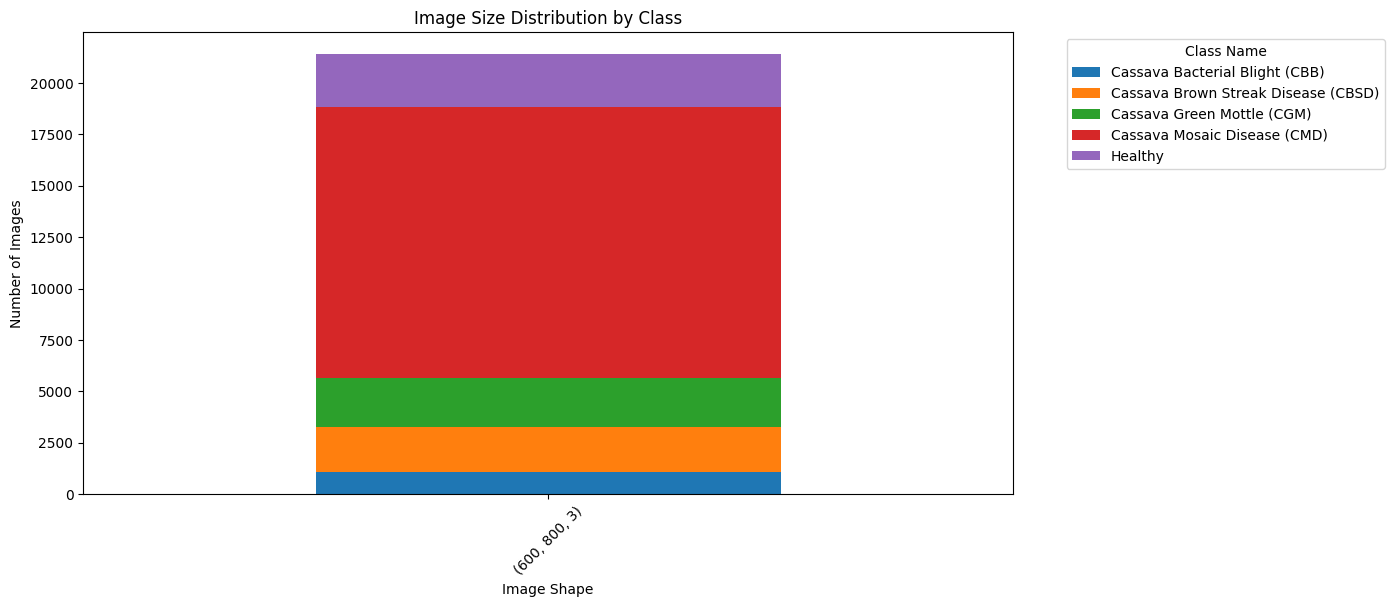

In [31]:
# Step 10: Check image shapes for the entire dataset
df_train['image_shape'] = df_train['image_id'].apply(lambda x: cv2.imread(os.path.join(BASE_DIR, "train_images", x)).shape)

# Group by class and image shape to see if there's a pattern in image size by disease type
shape_class_dist = df_train.groupby(['class_name', 'image_shape']).size().unstack(fill_value=0)

# Plot the distribution of image sizes for each class
shape_class_dist.T.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Image Size Distribution by Class')
plt.xlabel('Image Shape')
plt.ylabel('Number of Images')
plt.legend(title='Class Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

Step 1 : Analyzing the Patient¶
What would be a first step that a Leaf doctor should do before anything considering the fact that his client can't speak ? The answer is simple right , analyze what's wrong by looking at the patient

But how does a doctor understands if something is wrong by just looking at it? For this as a doctor , he should know what a normal Patient/Leaf looks like and observe deviations (in pattern ,color, texture,etc) from the normal behavior to separate the healthy patients from infected ones . Now to further classify the infected ones into specific class of diseases doctor should also know how the patient/leaf condition looks like in different diseases

With these pointers in mind let's start with basic familarity

This can help you understand if certain classes are more commonly associated with specific image sizes, which might indicate that certain images were taken under different conditions or with different devices.

In [32]:
df_train.head()

,image_id,label,class_name,image_shape
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),"(600, 800, 3)"
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)"
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)"
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)"
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)"


In [33]:
df_train['label_names'] = df_train['label'].map(map_classes)

# Duplicate Images

In [34]:
# Finding Duplicate Images
# Identifying Exact Duplicate Images

def get_image_hash(image_path):
    """Generate an MD5 hash for the image."""
    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    return file_hash

# Dictionary to store image hashes and their file names
image_hashes = {}

# Check for duplicate images
duplicate_images = []

for image_name in os.listdir(os.path.join(BASE_DIR, "train_images")):
    image_path = os.path.join(BASE_DIR, "train_images", image_name)
    image_hash = get_image_hash(image_path)
    
    if image_hash in image_hashes:
        duplicate_images.append((image_name, image_hashes[image_hash]))  # Image is a duplicate
    else:
        image_hashes[image_hash] = image_name  # Store the hash

print(f"Found {len(duplicate_images)} exact duplicate images.")
for dup in duplicate_images:
    print(f"Duplicate pair: {dup[0]} and {dup[1]}")

Found 0 exact duplicate images.


In [35]:
len(image_hashes)

21397

# Model -- 1 : Let's train Base Model

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model architecture
model = models.Sequential()

# 1st Convolutional block
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# 2nd Convolutional block
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# 3rd Convolutional block
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# 4th Convolutional block
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output to feed it into fully connected layers
model.add(layers.Flatten())

# Dense layer with 512 units
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

# Output layer for classification (assuming 5 classes)
model.add(layers.Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Assuming sparse labels (integers)
              metrics=['accuracy'])

# Model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,269,829 (73.51 MB)

 Trainable params: 19,267,845 (73.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [37]:
df_train.head()

,image_id,label,class_name,image_shape,label_names
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),"(600, 800, 3)",Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)


In [38]:
images_dir = '/kaggle/input/cassava-leaf-disease-classification/train_images'

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Create an ImageDataGenerator to preprocess images
datagen = ImageDataGenerator(rescale=1./255,
                            validation_split=0.2)  # Normalize pixel values

images_dir = '/kaggle/input/cassava-leaf-disease-classification/train_images'

# Generate training and validation datasets
train_dataset = datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=images_dir,
    x_col="image_id",  # Assuming the image path column is named "image_path"
    y_col="class_name",
    target_size=(224, 224),  # Adjust image size as needed
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_dataset = datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=images_dir,
    x_col="image_id",
    y_col="class_name",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [40]:
# # Train the model for 10 epochs
# history = model.fit(
#     train_dataset,   # Assumed preprocessed training dataset
#     validation_data=val_dataset,  # Assumed preprocessed validation dataset
#     epochs=1
# )

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


535/535 ━━━━━━━━━━━━━━━━━━━━ 129s 216ms/step - accuracy: 0.4999 - loss: 1.6289 - val_accuracy: 0.1596 - val_loss: 3.8081


In [41]:
# Train the model for 10 epochs
history = model.fit(
    train_dataset,   # Assumed preprocessed training dataset
    validation_data=val_dataset,  # Assumed preprocessed validation dataset
    epochs=10
)

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 106s 197ms/step - accuracy: 0.6500 - loss: 0.9710 - val_accuracy: 0.6574 - val_loss: 0.8727
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 101s 186ms/step - accuracy: 0.6885 - loss: 0.8298 - val_accuracy: 0.6691 - val_loss: 1.0143
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 101s 187ms/step - accuracy: 0.7233 - loss: 0.7325 - val_accuracy: 0.5695 - val_loss: 1.1397
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 102s 189ms/step - accuracy: 0.7525 - loss: 0.6622 - val_accuracy: 0.6908 - val_loss: 0.8701
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 99s 183ms/step - accuracy: 0.7922 - loss: 0.5658 - val_accuracy: 0.6205 - val_loss: 1.0757
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 99s 184ms/step - accuracy: 0.8071 - loss: 0.5207 - val_accuracy: 0.7469 - val_loss: 0.6992
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 100s 184ms/step - accuracy: 0.8712 - loss: 0.3568 - val_accuracy: 0.6815 - val_loss: 1.3401
Epoch 8/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 98s 181ms/step - accuracy: 0.9227 - lo

In [42]:
df_train.head()

,image_id,label,class_name,image_shape,label_names
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),"(600, 800, 3)",Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)


# Method 2 -- Using Tensorlfow Dataset

In [43]:
# Option 1: Using pandas' vectorized string operations
df_train['image_id'] = "/kaggle/input/cassava-leaf-disease-classification/train_images/" + df_train['image_id']
df_train.head()

,image_id,label,class_name,image_shape,label_names
0,/kaggle/input/cassava-leaf-disease-classificat...,0,Cassava Bacterial Blight (CBB),"(600, 800, 3)",Cassava Bacterial Blight (CBB)
1,/kaggle/input/cassava-leaf-disease-classificat...,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)
2,/kaggle/input/cassava-leaf-disease-classificat...,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
3,/kaggle/input/cassava-leaf-disease-classificat...,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
4,/kaggle/input/cassava-leaf-disease-classificat...,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)


In [44]:
from sklearn.model_selection import train_test_split

# Define the validation split ratio
VALIDATION_SPLIT = 0.2  # 20% for validation

# Perform stratified split to maintain class distribution
train_df, val_df = train_test_split(
    df_train,
    test_size=VALIDATION_SPLIT,
    stratify=df_train['label'],
    random_state=42
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples: 17117
Validation samples: 4280


In [45]:
print("Training class distribution:")
print(train_df['label'].value_counts())

print("\nValidation class distribution:")
print(val_df['label'].value_counts())


Training class distribution:
label
3    10526
4     2061
2     1909
1     1751
0      870
Name: count, dtype: int64

Validation class distribution:
label
3    2632
4     516
2     477
1     438
0     217
Name: count, dtype: int64


In [46]:
# Image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

# Batch size
BATCH_SIZE = 32

# Buffer size for shuffling
BUFFER_SIZE = 1000

# AUTOTUNE for performance optimization
AUTOTUNE = tf.data.AUTOTUNE

In [47]:
def process_image(file_path, label):
    # Read the image from disk
    image = tf.io.read_file(file_path)
    
    # Decode the image (assuming JPEG format)
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    
    # Resize the image
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    
    # Normalize pixel values to [0,1]
    image = image / 255.0
    
    return image, label


In [48]:
df_train.head()

,image_id,label,class_name,image_shape,label_names
0,/kaggle/input/cassava-leaf-disease-classificat...,0,Cassava Bacterial Blight (CBB),"(600, 800, 3)",Cassava Bacterial Blight (CBB)
1,/kaggle/input/cassava-leaf-disease-classificat...,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)
2,/kaggle/input/cassava-leaf-disease-classificat...,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
3,/kaggle/input/cassava-leaf-disease-classificat...,1,Cassava Brown Streak Disease (CBSD),"(600, 800, 3)",Cassava Brown Streak Disease (CBSD)
4,/kaggle/input/cassava-leaf-disease-classificat...,3,Cassava Mosaic Disease (CMD),"(600, 800, 3)",Cassava Mosaic Disease (CMD)


In [49]:
# Create TensorFlow Dataset from training DataFrame
train_ds = tf.data.Dataset.from_tensor_slices((train_df['image_id'].values, train_df['label'].values))

# Map the processing function to each (image, label) pair
train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)

In [50]:
# Data Augmentation (optional but recommended)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.18),
    layers.RandomContrast(0.2),
])

def augment(image, label):
    image = data_augmentation(image)
    return image, label

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)

# Shuffle, batch, and prefetch
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [51]:
# Create TensorFlow Dataset from validation DataFrame
val_ds = tf.data.Dataset.from_tensor_slices((val_df['image_id'].values, val_df['label'].values))

# Map the processing function
val_ds = val_ds.map(process_image, num_parallel_calls=AUTOTUNE)

# Batch and prefetch
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [52]:
from tensorflow.keras import regularizers

num_classes = 5
# Define the CNN model architecture
def create_cnn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=5):
    model = models.Sequential([
        # 1st Convolutional block
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # 2nd Convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # 3rd Convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # 4th Convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(5, activation='softmax')
    ])
    
    return model

# Instantiate the model
model = create_cnn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=num_classes)

# Display the model architecture
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,085,573 (99.51 MB)

 Trainable params: 26,083,589 (99.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [53]:
# Compile the model
model.compile(
    optimizer='adam',  # You can experiment with different optimizers
    loss='categorical_crossentropy',  # Suitable for integer-encoded labels
    metrics=['accuracy']
)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Combine callbacks
callbacks = [early_stop, checkpoint, reduce_lr]

In [56]:
# # Train the model for 10 epochs
# history = model.fit(
#     train_dataset,   # Assumed preprocessed training dataset
#     validation_data=val_dataset,  # Assumed preprocessed validation dataset
#     epochs=1
# )

In [57]:
# Define the number of epochs
EPOCHS = 10  # Adjust based on your requirements

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.4886 - loss: 1.6650
Epoch 1: val_accuracy improved from -inf to 0.44356, saving model to best_cnn_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 116s 215ms/step - accuracy: 0.4887 - loss: 1.6644 - val_accuracy: 0.4436 - val_loss: 1.4354 - learning_rate: 0.0010
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6426 - loss: 0.9804
Epoch 2: val_accuracy improved from 0.44356 to 0.66511, saving model to best_cnn_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 99s 183ms/step - accuracy: 0.6426 - loss: 0.9804 - val_accuracy: 0.6651 - val_loss: 0.8835 - learning_rate: 0.0010
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6903 - loss: 0.8292
Epoch 3: val_accuracy improved from 0.66511 to 0.69152, saving model to best_cnn_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 180ms/step - accuracy: 0.6903 - loss: 0.8292 - val_accuracy: 0.6915 - val_loss: 0.8137 - learning_rate: 0.0010
Epoch 4/10
535/535 ━━━━━━━━

In [59]:
# # Step 14: Evaluate the Model
# val_loss, val_accuracy = model.evaluate(val_ds)
# print(f"\nValidation Loss: {val_loss:.4f}")
# print(f"Validation Accuracy: {val_accuracy:.4f}")

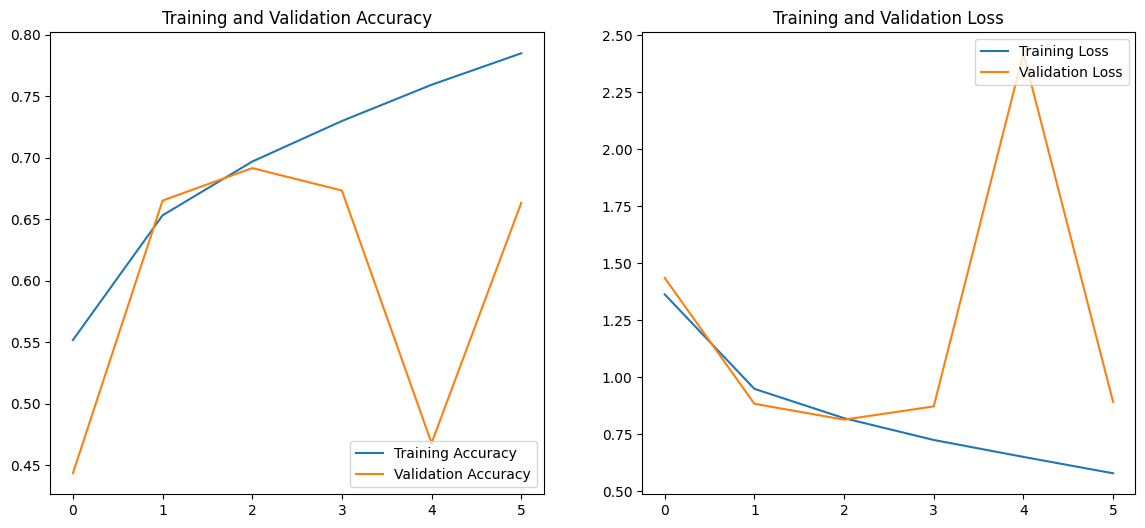

In [60]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot Accuracy
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Visualising the augmentations


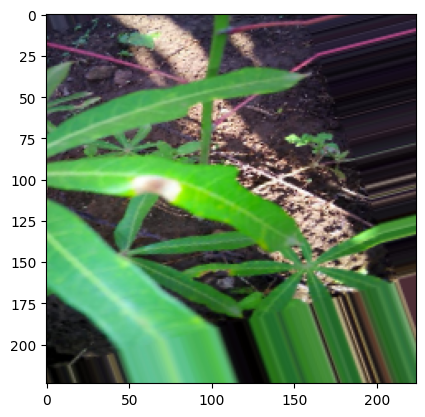

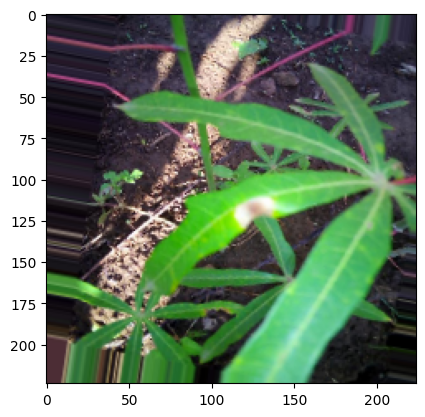

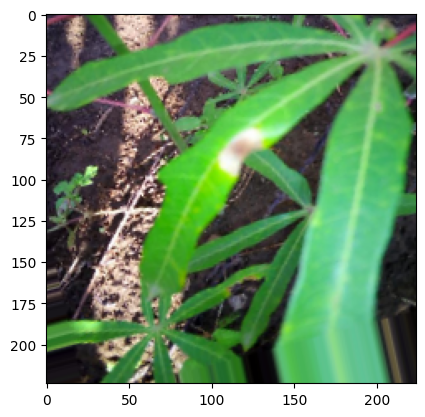

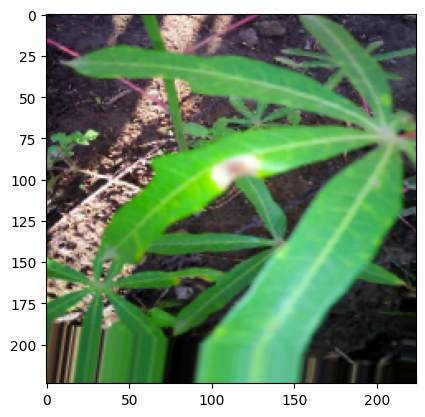

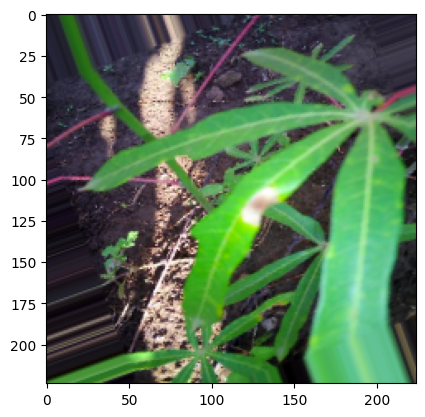

In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define your data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Example usage on one image
from tensorflow.keras.preprocessing import image

img = image.load_img('/kaggle/input/cassava-leaf-disease-classification/train_images/1001320321.jpg',
                     target_size=(224, 224))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)

# Generate 5 augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 5 == 0:
        break
plt.show()


# Understanding class weights 

In [62]:
# Compute class weights
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)
class_weights = dict(enumerate(class_weights))
class_weights

{0: 3.9368905243790246,
 1: 1.954956601187757,
 2: 1.7935456831517183,
 3: 0.3252317981456148,
 4: 1.6606131160263873}

# Implementing Focal Loss

In [ ]:
# !pip install tensorflow-addons

In [ ]:
# pip install --upgrade tensorflow

In [ ]:
# import tensorflow as tf
# import tensorflow-addons as tfa

In [ ]:
# import tensorflow as tf
# import tensorflow_addons as tfa

# print("TensorFlow:", tf.__version__)
# print("TensorFlow Addons:", tfa.__version__)


In [ ]:
# import tensorflow as tf

# class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
#     def __init__(self, gamma=2.0, alpha=None, name="sparse_categorical_focal_loss"):
#         super().__init__(name=name)
#         self.gamma = gamma
#         self.alpha = alpha  # list or array of class weights

#     def call(self, y_true, y_pred):
#         # Ensure predictions are clipped for stability
#         y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
#         y_true = tf.cast(y_true, tf.int32)

#         # One-hot encode true labels
#         y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

#         # Compute cross-entropy
#         cross_entropy = -y_true_oh * tf.math.log(y_pred)

#         # Compute focal loss factor
#         focal_factor = tf.pow(1 - y_pred, self.gamma)

#         # Apply alpha weights if provided
#         if self.alpha is not None:
#             alpha = tf.constant(self.alpha, dtype=tf.float32)
#             alpha_factor = y_true_oh * alpha
#             focal_loss = alpha_factor * focal_factor * cross_entropy
#         else:
#             focal_loss = focal_factor * cross_entropy

#         return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))


# # Convert class_weights dict to list if needed
# alpha = list(class_weights.values())

# # Instantiate the custom loss
# focal_loss = SparseCategoricalFocalLoss(gamma=2.0, alpha=alpha)

# # Compile your model
# model.compile(
#     optimizer='adam',
#     loss=focal_loss,
#     metrics=['accuracy']
# )


In [ ]:
# focal_loss = tfa.losses.SparseCategoricalFocalCrossentropy(
#     from_logits=False,  # Since the model outputs probabilities with softmax
#     alpha=class_weights,  # Class weights computed earlier
#     gamma=2.0  # Focusing parameter
# )

In [ ]:
# model.compile(
#     optimizer='adam',
#     loss=focal_loss,
#     metrics=['accuracy']
# )

In [ ]:
# history = model.fit(
#                     train_ds,
#                     validation_data=val_ds,
#                     epochs=10,
#                     callbacks=callbacks
#                    )

In [ ]:
# # Step 14: Evaluate the Model
# val_loss, val_accuracy = model.evaluate(val_ds)
# print(f"\nValidation Loss: {val_loss:.4f}")
# print(f"Validation Accuracy: {val_accuracy:.4f}")

# # Step 15: Save the Model
# model.save('cnn_cassava_leaf_disease_focal_loss.keras')
# print("\nModel saved successfully!")

In [ ]:
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs_range = range(len(acc))

# # Plot Accuracy
# plt.figure(figsize=(14, 6))
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, acc, label='Training Accuracy')
# plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# plt.legend(loc='lower right')
# plt.title('Training and Validation Accuracy')

# # Plot Loss
# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, loss, label='Training Loss')
# plt.plot(epochs_range, val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.title('Training and Validation Loss')

# plt.show()

### Implementing Transfer Learning RESNET
### Home work fine tuning.
### Model training, plotting, evalution, confusion matirix.

In [66]:
# from tensorflow.keras.applications import ResNet50

# # Effecient net

# # Load the ResNet50 model without the top classification layers
# base_model = ResNet50(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# # Freeze the base model
# base_model.trainable = False

# # Create a new model on top
# model = models.Sequential([
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(256, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dense(512, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dropout(0.5),
#     layers.Dense(5, activation='softmax')
# ])

# # Compile with Focal Loss
# model.compile(
#     optimizer='adam',
#     loss='categorial_cross_entropy',
#     metrics=['accuracy']
# )

# # Model summary
# model.summary()

# Transfer Leanring Effecient Net

In [67]:
# Step 1: Import Necessary Libraries
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# import tensorflow_addons as tfa

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB3


In [68]:
# Step 2: Define Paths
work_dir = '../input/cassava-leaf-disease-classification/'  # Update if necessary
train_path = os.path.join(work_dir, 'train_images')  # Path to training images
train_csv_path = os.path.join(work_dir, 'train.csv')  # Path to train.csv
label_map_path = os.path.join(work_dir, 'label_num_to_disease_map.json')  # Path to label mapping JSON


In [69]:
# a. Load Train Data
data = pd.read_csv(train_csv_path)
print("Initial DataFrame:")
print(data.head())

# Check label frequencies
print("\nLabel Frequencies:")
print(Counter(data['label']))


Initial DataFrame:
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

Label Frequencies:
Counter({3: 13158, 4: 2577, 2: 2386, 1: 2189, 0: 1087})


In [70]:
# b. Load Label Mapping
with open(label_map_path, 'r') as f:
    real_labels = json.load(f)

# Convert string keys to integers
real_labels = {int(k): v for k, v in real_labels.items()}

# Map label numbers to class names
data['class_name'] = data['label'].map(real_labels)
print("\nDataFrame with 'class_name':")
print(data.head())



DataFrame with 'class_name':
         image_id  label                           class_name
0  1000015157.jpg      0       Cassava Bacterial Blight (CBB)
1  1000201771.jpg      3         Cassava Mosaic Disease (CMD)
2   100042118.jpg      1  Cassava Brown Streak Disease (CBSD)
3  1000723321.jpg      1  Cassava Brown Streak Disease (CBSD)
4  1000812911.jpg      3         Cassava Mosaic Disease (CMD)


In [71]:

# Step 4: Compute Class Weights
labels = data['label'].values  # Integer-encoded labels

# Compute class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Create a dictionary mapping class indices to weights
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print("\nClass Weights:")
print(class_weights_dict)


Class Weights:
{0: 3.9368905243790246, 1: 1.954956601187757, 2: 1.7935456831517183, 3: 0.3252317981456148, 4: 1.6606131160263873}


In [72]:
# Step 5: Define ImageDataGenerators
IMG_SIZE = 224
TARGET_SIZE = (IMG_SIZE, IMG_SIZE)
NUM_CLASSES = 5  # Update based on actual number of classes
BATCH_SIZE = 15


In [73]:
datagen_train = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,  # EfficientNet preprocessing
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)


In [74]:
# ImageDataGenerator for validation (only normalization)
datagen_val = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input  # EfficientNet preprocessing
)

In [75]:
train_df, val_df = train_test_split(
    data,
    test_size=0.05,  # 5% for validation
    random_state=42,
    stratify=data['class_name']
)
print(f"\nNumber of training samples: {len(train_df)}")
print(f"Number of validation samples: {len(val_df)}")


Number of training samples: 20327
Number of validation samples: 1070


In [76]:
train_set = datagen_train.flow_from_dataframe(train_df,
                             directory = train_path,
                             seed=42,
                             x_col = 'image_id',
                             y_col = 'class_name',
                             target_size = TARGET_SIZE,
                             #color_mode="rgb",
                             class_mode = 'categorical',
                             interpolation = 'nearest',
                             shuffle = True,
                             batch_size = BATCH_SIZE)

val_set = datagen_val.flow_from_dataframe(val_df,
                             directory = train_path,
                             seed=42,
                             x_col = 'image_id',
                             y_col = 'class_name',
                             target_size = TARGET_SIZE,
                             #color_mode="rgb",
                             class_mode = 'categorical',
                             interpolation = 'nearest',
                             shuffle = True,
                             batch_size = BATCH_SIZE)

Found 20327 validated image filenames belonging to 5 classes.
Found 1070 validated image filenames belonging to 5 classes.


In [78]:
base_model = EfficientNetB3(input_shape=(224, 224, 3), include_top=False, 
                                weights='imagenet')

base_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 40)   │          1,080 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 40)   │            160 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 40)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 40)   │            360 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 40)   │            160 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 40)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 40)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 40)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 10)       │            410 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 10,696,232 (40.80 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [80]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB3

# Set up the model
model = Sequential()

# Add an input layer
model.add(tf.keras.Input(shape=(224, 224, 3)))

# Add EfficientNetB3 base model
base_model = EfficientNetB3(include_top=False, weights='imagenet')
model.add(base_model)

# Now the model is built, you can call summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)          │ (None, 7, 7, 1536)          │      10,783,535 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 10,696,232 (40.80 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [83]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import EfficientNetB3

def create_model():
    
    model = Sequential()
    # Add an input layer
    model.add(tf.keras.Input(shape=(224, 224, 3)))
    
    # Initialize EfficientNetB3 with input_shape explicitly defined
    base_model = EfficientNetB3(input_shape=(224, 224, 3), include_top=False, 
                                weights='imagenet')
    
    # Freeze layers (except last 40 layers)
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    
    # Add the base model
    model.add(base_model)
    
    # Add global average pooling layer
    model.add(GlobalAveragePooling2D())
    
    # Add Dense layer with regularization
    model.add(Dense(256, activation='relu', 
                    bias_regularizer=tf.keras.regularizers.L1L2(l1=0.01, l2=0.001)))
    
    # Add Dropout layer
    model.add(Dropout(0.5))
    
    # Add output Dense layer for classification (5 classes)
    model.add(Dense(5, activation='softmax'))
    
    return model

# Create and summarize the model
leaf_model = create_model()
leaf_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)          │ (None, 7, 7, 1536)          │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         393,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,178,292 (42.64 MB)

 Trainable params: 4,758,201 (18.15 MB)

 Non-trainable params: 6,420,091 (24.49 MB)

In [89]:
EPOCHS = 5
STEP_SIZE_TRAIN = train_set.n//train_set.batch_size
STEP_SIZE_VALID = val_set.n//val_set.batch_size

In [90]:
def Model_fit():
    
    #leaf_model = None
    
    leaf_model = create_model()
    
    '''Compiling the model'''
    
    loss = tf.keras.losses.CategoricalCrossentropy(from_logits = False,
                                                   label_smoothing=0.0001,
                                                   name='categorical_crossentropy' )
    
    leaf_model.compile(optimizer = Adam(learning_rate = 1e-3),
                        loss = loss, #'categorical_crossentropy'
                        metrics = ['categorical_accuracy']) #'acc'
    
    # Stop training when the val_loss has stopped decreasing for 3 epochs.
    es = EarlyStopping(monitor='val_loss', mode='min', patience=3,
                       restore_best_weights=True, verbose=1)
    
    # Save the model with the minimum validation loss
    checkpoint_cb = ModelCheckpoint("Cassava_best_model.keras",
                                    save_best_only=True,
                                    monitor = 'val_loss',
                                    mode='min')
    # reduce learning rate
    reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                                  factor = 0.2,
                                  patience = 2,
                                  min_lr = 1e-6,
                                  mode = 'min',
                                  verbose = 1)
    
    history = leaf_model.fit(train_set,
                             validation_data = val_set,
                             epochs= EPOCHS,
                             batch_size = BATCH_SIZE,
                             # class_weight = d_class_weights,
                             steps_per_epoch = STEP_SIZE_TRAIN,
                             validation_steps = STEP_SIZE_VALID,
                             callbacks=[es, checkpoint_cb, reduce_lr])
    
    leaf_model.save('Cassava_model'+'.keras')  
    
    return history

In [91]:
results = Model_fit()

Epoch 1/5
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 357s 236ms/step - categorical_accuracy: 0.6698 - loss: 0.9266 - val_categorical_accuracy: 0.6911 - val_loss: 0.8296 - learning_rate: 0.0010
Epoch 2/5
   1/1355 ━━━━━━━━━━━━━━━━━━━━ 1:01 45ms/step - categorical_accuracy: 0.7333 - loss: 0.7299

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1355/1355 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - categorical_accuracy: 0.7333 - loss: 0.7299 - val_categorical_accuracy: 0.8000 - val_loss: 0.4606 - learning_rate: 0.0010
Epoch 3/5
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 293s 215ms/step - categorical_accuracy: 0.7510 - loss: 0.7158 - val_categorical_accuracy: 0.7653 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 4/5
   1/1355 ━━━━━━━━━━━━━━━━━━━━ 58s 43ms/step - categorical_accuracy: 0.7333 - loss: 0.8261
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 0s 30us/step - categorical_accuracy: 0.7333 - loss: 0.8261 - val_categorical_accuracy: 0.6000 - val_loss: 1.1134 - learning_rate: 0.0010
Epoch 5/5
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 298s 219ms/step - categorical_accuracy: 0.7829 - loss: 0.6136 - val_categorical_accuracy: 0.7944 - val_loss: 0.5830 - learning_rate: 2.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [92]:
print('Train_Cat-Acc: ', max(results.history['categorical_accuracy']))
print('Val_Cat-Acc: ', max(results.history['val_categorical_accuracy']))

Train_Cat-Acc:  0.7844623923301697
Val_Cat-Acc:  0.800000011920929


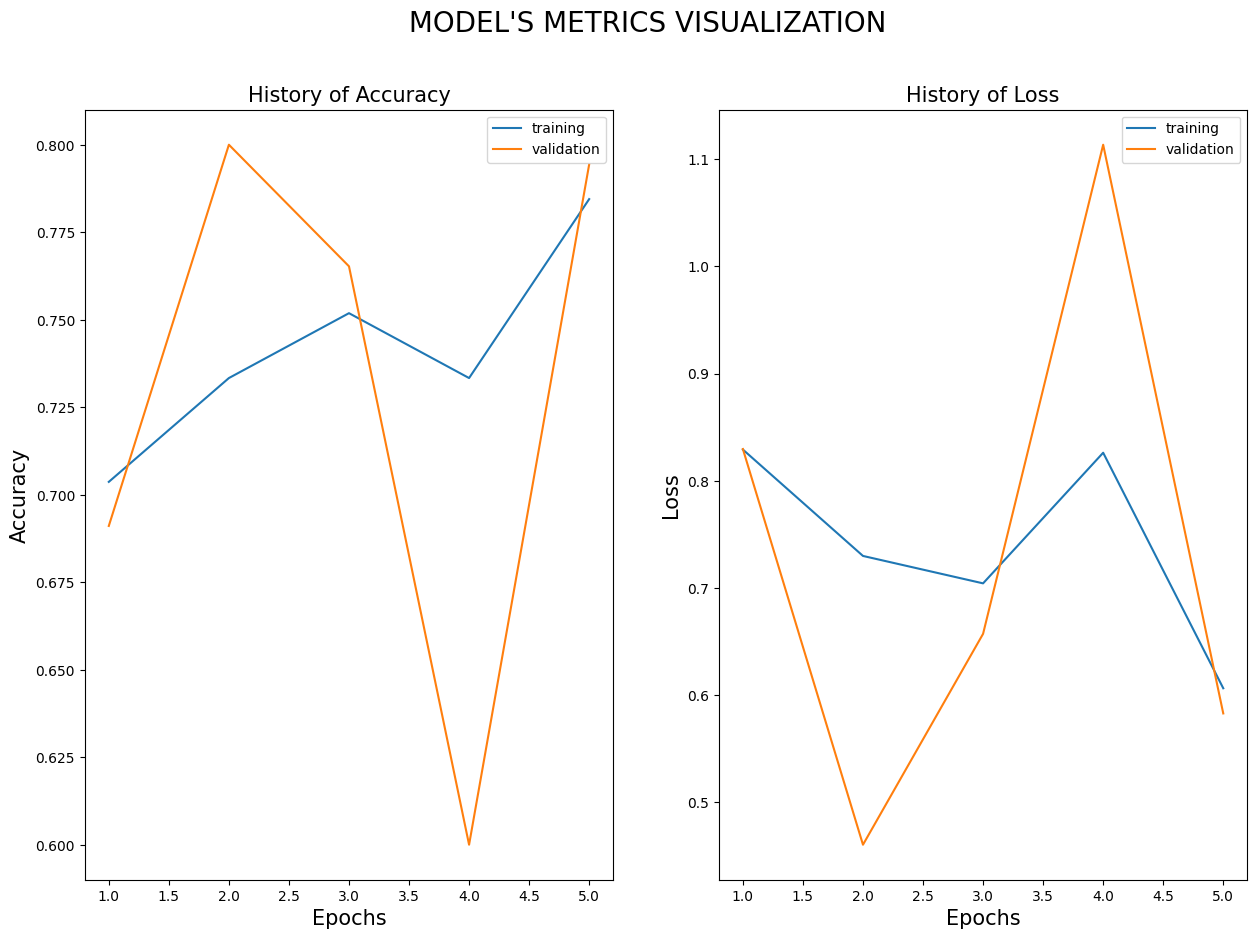

In [93]:
def Train_Val_Plot(acc,val_acc,loss,val_loss):
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize= (15,10))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ", fontsize=20)

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy', fontsize=15)
    ax1.set_xlabel('Epochs', fontsize=15)
    ax1.set_ylabel('Accuracy', fontsize=15)
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss', fontsize=15)
    ax2.set_xlabel('Epochs', fontsize=15)
    ax2.set_ylabel('Loss', fontsize=15)
    ax2.legend(['training', 'validation'])
    plt.show()
    

Train_Val_Plot(results.history['categorical_accuracy'],results.history['val_categorical_accuracy'],
               results.history['loss'],results.history['val_loss'])

In [95]:
# # EVALUATING THE MODEL

# import keras

# final_model = keras.models.load_model('Cassava_best_model.keras')

# Test Time Augmentaiton

In [ ]:
TEST_DIR = '../input/cassava-leaf-disease-classification/test_images/'
test_images = os.listdir(TEST_DIR)
datagen = ImageDataGenerator(horizontal_flip=True)


def pred(images):
    for image in test_images:
        img = Image.open(TEST_DIR + image)
        img = img.resize(size)
        samples = np.expand_dims(img, axis=0)
        it = datagen.flow(samples, batch_size=10)
        yhats = final_model.predict_generator(it, steps=10, verbose=0)
        summed = np.sum(yhats, axis=0)
    return np.argmax(summed)

predictions = pred(test_images)